In [8]:
import operator
from typing import TypedDict, List, Annotated, Literal, Optional

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

In [9]:
class Task(BaseModel): #inheriting from pydantic base model
    id: int
    title: str
    goal: str = Field(...,description="What the reader should be able to understand from this")
    main_pts : str = Field(...,  min_length=3, max_length= 5, description="Make 3-4 non overlapping points to cover in this section") 
    word_count : str = Field(..., description="Word count for this section should be around 100-400 words")
    section_type: Literal["intro", "core", "examples", "checklist", "common_mistakes", "conclusion"] = Field(...,description="Use 'common_mistakes' exactly once in the plan.")
    tages: List[str] = Field(...,default_factory=list)
    requires_research: bool = False
    requires_citation: bool= False
    requires_code : bool = False

class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None

class RouterDecision(BaseModel):
    research_required: bool = False
    mode: Literal["closed","hybrid","online"]
    queries: List[str] = Field(..., default_factory=list)

class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)



In [10]:
class Plan(BaseModel):
    blog_title: str
    audience: str = Field(...,description="Who this blog is for")
    tone: str = Field(..., description="Writing tone (e.g. practical, informal)")
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

In [11]:
class State(TypedDict): #Dictionary with this type of keys and val
    topic: str
    plan: Optional[Plan]
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[tuple[int,str]], operator.add]
    final: str

In [14]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os
load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.6
)

In [13]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.
                    Decide whether web research is needed BEFORE planning.
                    Modes:
                    closed_book (needs_research=false):
                      Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
                    hybrid (needs_research=true):
                      Mostly evergreen but needs up-to-date examples/tools/models to be useful.
                    online (needs_research=true):
                      Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

                    If needs_research=true:
                     Output 3–10 high-signal queries.
                     Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
                     If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
                """
def router_node(state: State) -> dict :
    response = llm.with_structured_output(RouterDecision).invoke(
        [
            SystemMessage(
                    content=ROUTER_SYSTEM
                ),
            HumanMessage(
                content=f"Topic: {state["topic"]}"
            )
        ]
    )
    return {
        "needs_research" : response.research_required,
        "mode": response.mode,
        "queries": response.queries,
    }

def route_next(state: State) -> str:
    if state["needs_research"]: 
        return "research"
    else:
        return "orchestrator"

In [15]:
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.
                    Given raw web search results, produce a deduplicated list of EvidenceItem objects.
                    Rules:
                     Only include items with a non-empty url.
                     Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
                     If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
                     If missing or unclear, set published_at=null. Do NOT guess.
                     Keep snippets short.
                     Deduplicate by URL.
                    """
def research_node(state : State) -> dict :
    queries = state["queries"]
    max_result = 2
    results: List[dict] = []
    for query in queries:
        results.extend(tavily_search(query,max_result))
    if not results:
        return {"evidence" : []}
    response = llm.with_structured_output(EvidencePack).invoke(
        [
            SystemMessage(
                content=RESEARCH_SYSTEM
            ),
            HumanMessage(
                content= f"Raw results {results}\n"
            )
        ]
    )
    dedup = {}
    for e in response.evidence:
        if e.url:
            dedup[e.url] = e
    return {"evidence" : list(dedup.values)}



#Tavily Search
def tavily_search(query: str, max_results: int = 2) -> List[dict]:
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query" : query})
    response_res : List[dict] = []
    for r in results:
        response_res.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return response_res

In [16]:
import json
ORCHESTRATOR_SYSTEM = """You are a principal engineer and technical editor.
Your task is to design a high-quality, implementation-oriented outline for a technical blog post.
Hard requirements:
- Produce 5–9 well-scoped sections appropriate for the topic and audience.
- Each section must include:
  1) goal (one clear outcome sentence: what the reader will be able to do or understand)
  2) 3–6 actionable, non-overlapping bullets
  3) target word count (120–550)
- Sections must follow a logical progression (foundations → implementation → trade-offs → validation → wrap-up).

Quality standards:
- Assume a technical audience; use precise engineering terminology.
- Bullets must describe concrete actions (implement, benchmark, validate, refactor, test, inspect, monitor).
- Avoid vague phrasing (no “discuss” or “explore”).
- Across the full outline, include at least TWO of the following:
  * minimal working example or code sketch (set requires_code=True for that section)
  * edge cases or failure modes
  * performance or cost analysis
  * security or privacy implications (if relevant)
  * testing, monitoring, or observability guidance

Structural guidance:
- Begin with problem framing and constraints.
- Build conceptual clarity before advanced details.
- Include one section focused on common mistakes or pitfalls.
- End with a practical summary, checklist, or next steps.

Grounding modes:
- Mode: closed_book
  - Produce an evergreen, concept-driven outline.
  - Do not rely on external evidence.
- Mode: hybrid
  - Use evidence only for time-sensitive examples (tools, releases, benchmarks).
  - Mark sections that depend on fresh information with:
    requires_research=True and requires_citations=True.
- Mode: open_book
  - Set blog_kind="news_roundup".
  - Each section must summarize developments and analyze implications.
  - Do not include tutorial sections unless explicitly requested.
  - If evidence is insufficient, explicitly state "insufficient sources" in the outline
    and limit claims to verifiable information.
Output must strictly conform to the Plan schema.
Return only structured data. No commentary.
"""
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=ORCHESTRATOR_SYSTEM
            ),
            HumanMessage(content=
                    f"Topic: {state['topic']}\n"
                    f"Mode: {state["mode"]}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in state["evidence"]][:16]}")  #model_dump convers pydantic object to dictionary
        ]
    )
    print(plan)
    return {"plan": plan}

In [17]:
import time
WORKER_SYSTEM = """You are a principal engineer and technical editor.
Write EXACTLY ONE section of a technical blog post in Markdown.

Execution constraints:
- Start with: ## <Section Title>
- Follow the provided Goal precisely.
- Address ALL Bullets in the given order.
- Do NOT merge, skip, or reorder bullets.
- Stay within Target words (±15%).
- Output ONLY the section content (no extra commentary, no H1 title, no meta text).

Scope guard:
- If blog_kind == "news_roundup":
  - Do NOT convert this into a tutorial or implementation guide.
  - Focus on summarizing events and analyzing implications.
  - Only explain mechanics if explicitly required by bullets.

Grounding rules:
- If mode == "open_book":
  - Every real-world claim (event, company, model, release, funding, regulation, benchmark)
    MUST be supported by a provided Evidence URL.
  - Attach citations inline using Markdown links: ([Source](URL)).
  - Use ONLY URLs from the provided Evidence.
  - If a claim cannot be supported, write exactly:
    "Not found in provided sources."
- If requires_citations == true:
  - Cite external-world claims using provided Evidence URLs.
- If evidence is empty and citations are required:
  - State: "Insufficient sources provided."

Reasoning policy:
- Evergreen conceptual explanations do NOT require citations unless requires_citations == true.
- Do NOT hallucinate dates, statistics, product versions, or funding numbers.

Code requirements:
- If requires_code == true:
  - Include at least one minimal, correct, idiomatic code snippet.
  - Code must directly support one of the bullets.
  - Keep snippets concise and executable.

Technical quality bar:
- Be precise and implementation-oriented.
- Prefer concrete APIs, data structures, protocols, and workflows.
- Briefly mention trade-offs where relevant (performance, cost, reliability, security).
- Call out at least one edge case or failure mode if applicable to the section.

Style:
- Use short paragraphs.
- Use bullet lists where helpful.
- Use fenced code blocks for code.
- Avoid fluff, repetition, or marketing language.
"""
def worker(state: State) -> dict :
    sections = []
    plan = state["plan"]
    for task in state["plan"].tasks:
        output = llm.invoke(
            [
                SystemMessage(content=WORKER_SYSTEM),
                HumanMessage(content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {state['topic']}\n"
                    f"Mode: {state['mode']}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.word_count}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citation}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{task.main_pts}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{state['evidence']}\n"
                ))
            ]
        ).content.strip()
        sections.append(output)
        time.sleep(12)
    return {"sections": [task.id,sections]}

In [18]:
from pathlib import Path
def reducer(state: State) -> dict :
    title = state["plan"].blog_title
    content = "\n\n".join(state["sections"]).strip()

    final_md = f"#{title}\n\n{content}\n"
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


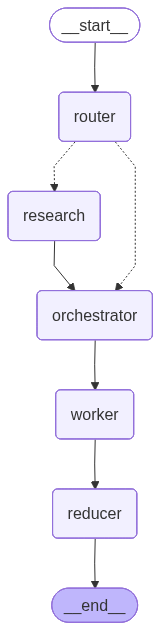

In [19]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_edge("orchestrator", "worker")
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [ ]:
out = app.invoke({'topic': "Write a blog on Stock market"})


blog_title='Understanding the Stock Market' tasks=[Task(id=1, title='What is the Stock Market?', brief='Introduction to the stock market'), Task(id=2, title='Types of Stocks and Shares', brief='Types of stocks and shares'), Task(id=3, title='How to Invest in the Stock Market', brief='How to invest in the stock market'), Task(id=4, title='Risks and Rewards of Investing in the Stock Market', brief='Risks and rewards of investing in the stock market'), Task(id=5, title='Tips and Strategies for Success in the Stock Market', brief='Tips and strategies for success in the stock market'), Task(id=6, title='Common Stock Market Terms and Jargon', brief='Common stock market terms and jargon'), Task(id=7, title='Conclusion and Final Thoughts', brief='Conclusion and final thoughts')]


In [ ]:
print(out['plan'])

blog_title='Understanding the Stock Market' tasks=[Task(id=1, title='What is the Stock Market?', brief='Introduction to the stock market'), Task(id=2, title='Types of Stocks and Shares', brief='Types of stocks and shares'), Task(id=3, title='How to Invest in the Stock Market', brief='How to invest in the stock market'), Task(id=4, title='Risks and Rewards of Investing in the Stock Market', brief='Risks and rewards of investing in the stock market'), Task(id=5, title='Tips and Strategies for Success in the Stock Market', brief='Tips and strategies for success in the stock market'), Task(id=6, title='Common Stock Market Terms and Jargon', brief='Common stock market terms and jargon'), Task(id=7, title='Conclusion and Final Thoughts', brief='Conclusion and final thoughts')]
